In [26]:
%matplotlib widget

In [27]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [28]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [29]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelenght')

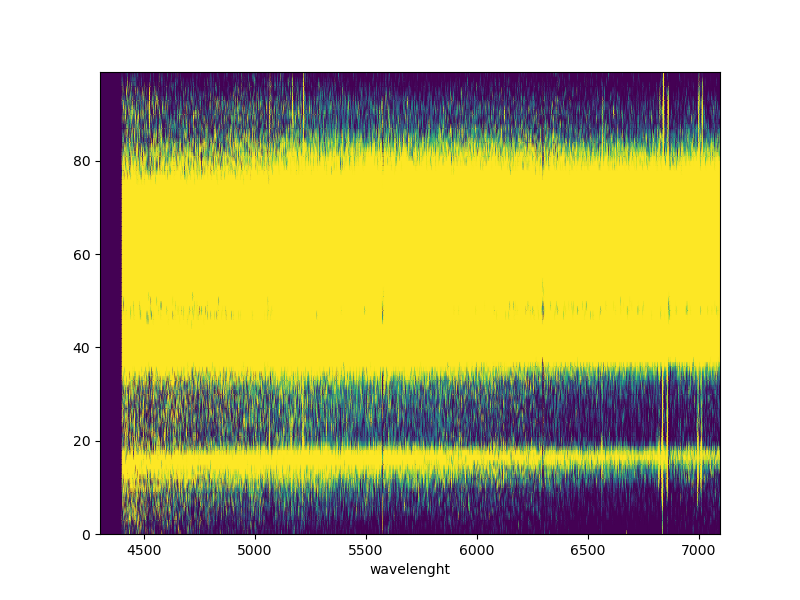

In [30]:
wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [31]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [32]:
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35
sigma = sigmas[-1]

In [33]:
sigmas

array([1.00391516, 1.0803587 , 1.00353273, 1.00194585, 1.0715137 ])

In [34]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, params1, params2, params3, params4, params5, params6):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4) +
        sersic_1d(x_hr, params5) + 
        sersic_1d(x_hr, params6)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def sersic_1d_convolved(x, sigma, params):
    """ Sérsic convoluto con PSF gaussiana """
    I_e, r_e, n, x_0 = params
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, params)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

In [35]:
def plot_sigma_HA(sigma_extraction, sigma_HA, x_axes, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_HA, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange', 'chocolate', 'purple']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigma_HA, np.array(fit[comp_name]))
        ax[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile H$\\alpha$ with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 100)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Halpha_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

## Halpha

Text(0.5, 1.0, 'H$\\alpha$')

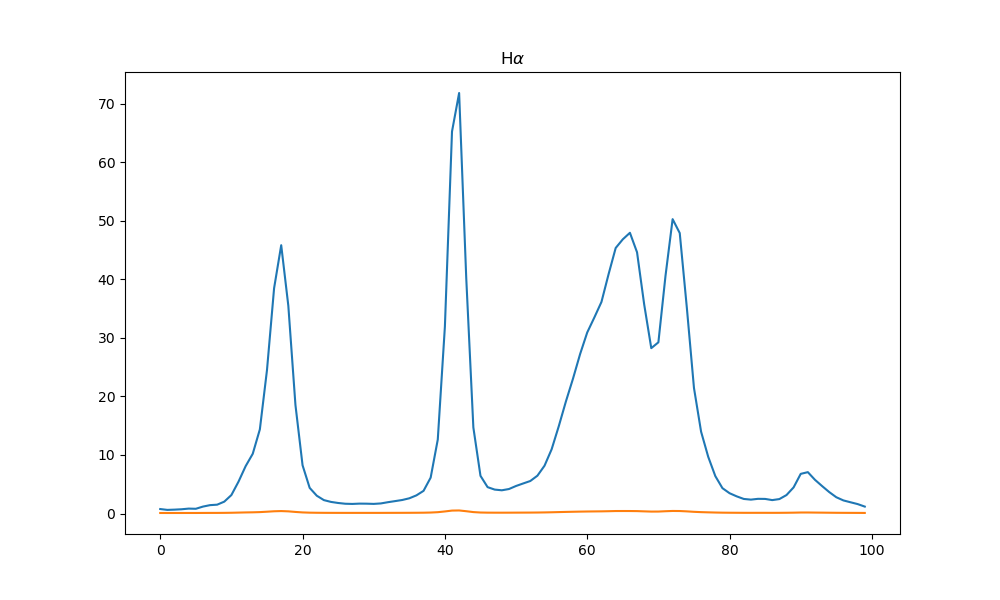

In [36]:
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

     Component 1  Component 2  Component 3  Component 4  Component 5  \
I_e       1.3189       2.8302       6.5184       9.3911       4.7418   
r_e      10.9768       4.6566       6.9821       4.4883       5.5578   
n         2.8420       3.0356       0.8845       0.9674       1.7061   
x_0      16.6268      41.6152      60.3210      65.5906      72.5908   

     Component 6  
I_e       0.9772  
r_e       6.7674  
n         1.3700  
x_0      91.2633  


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12956\2277517890.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./Halpha_1sigma.png
Plot salvato come: ./Halpha_2sigma.png
Plot salvato come: ./Halpha_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile H$\\alpha$ with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

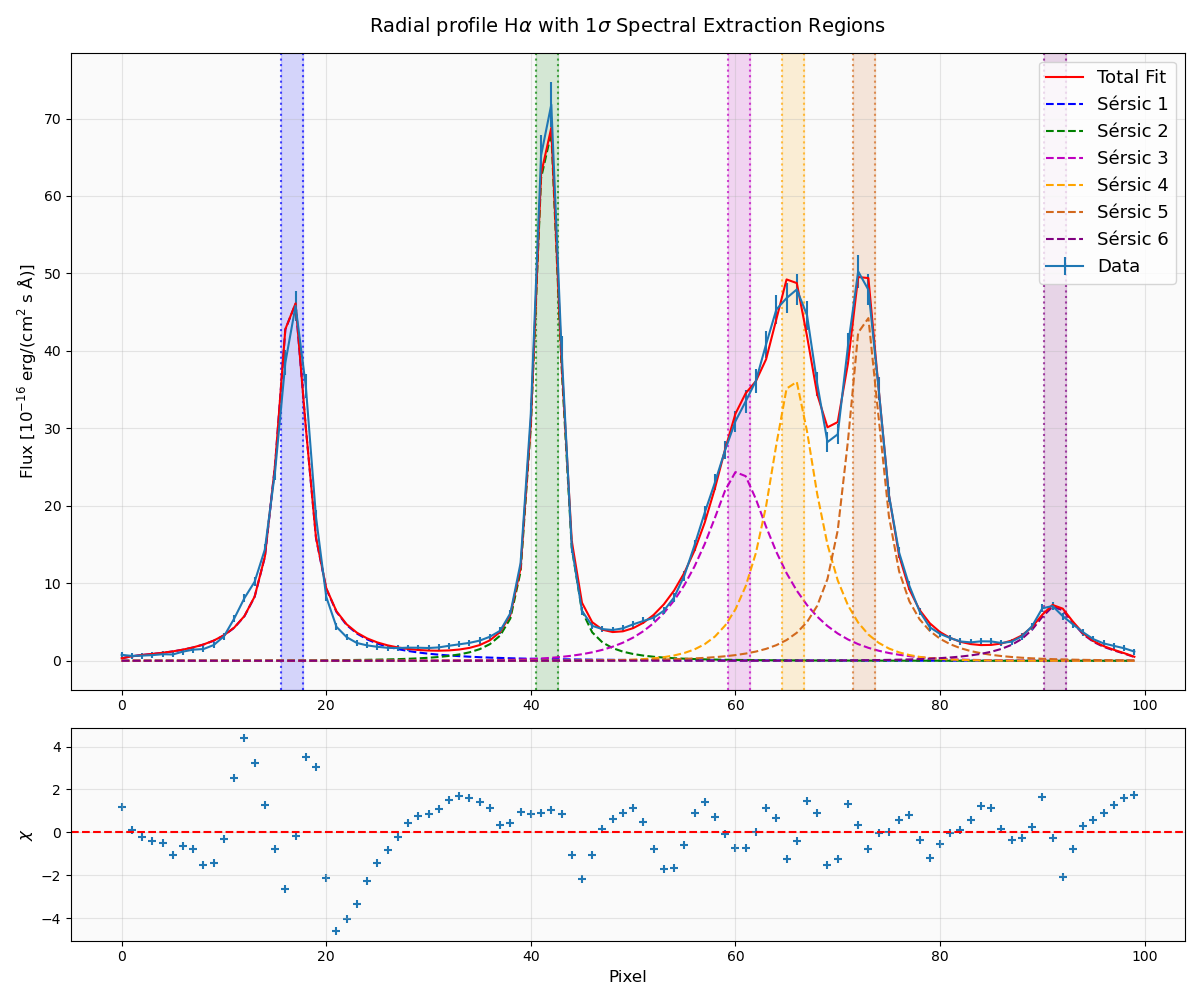

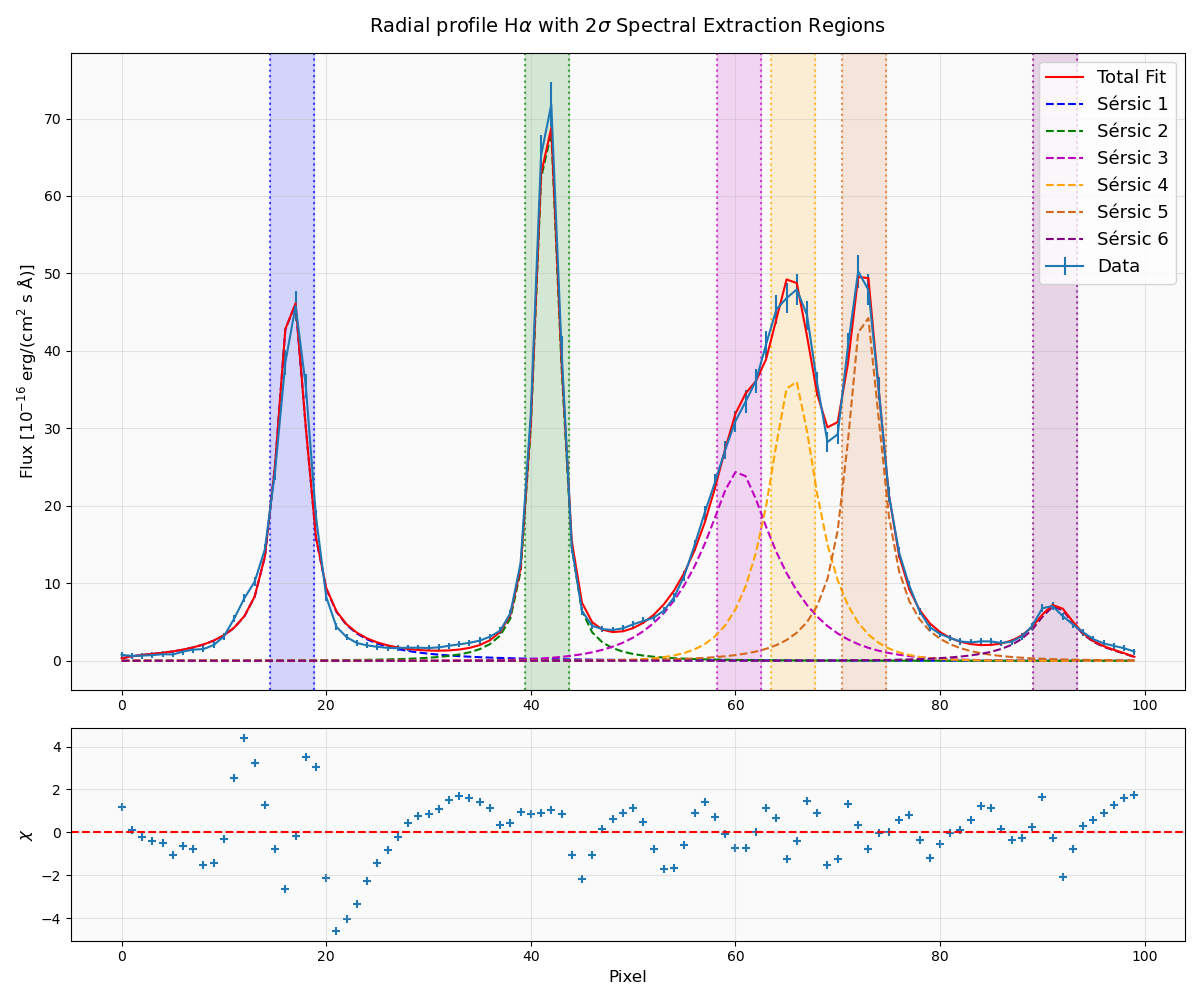

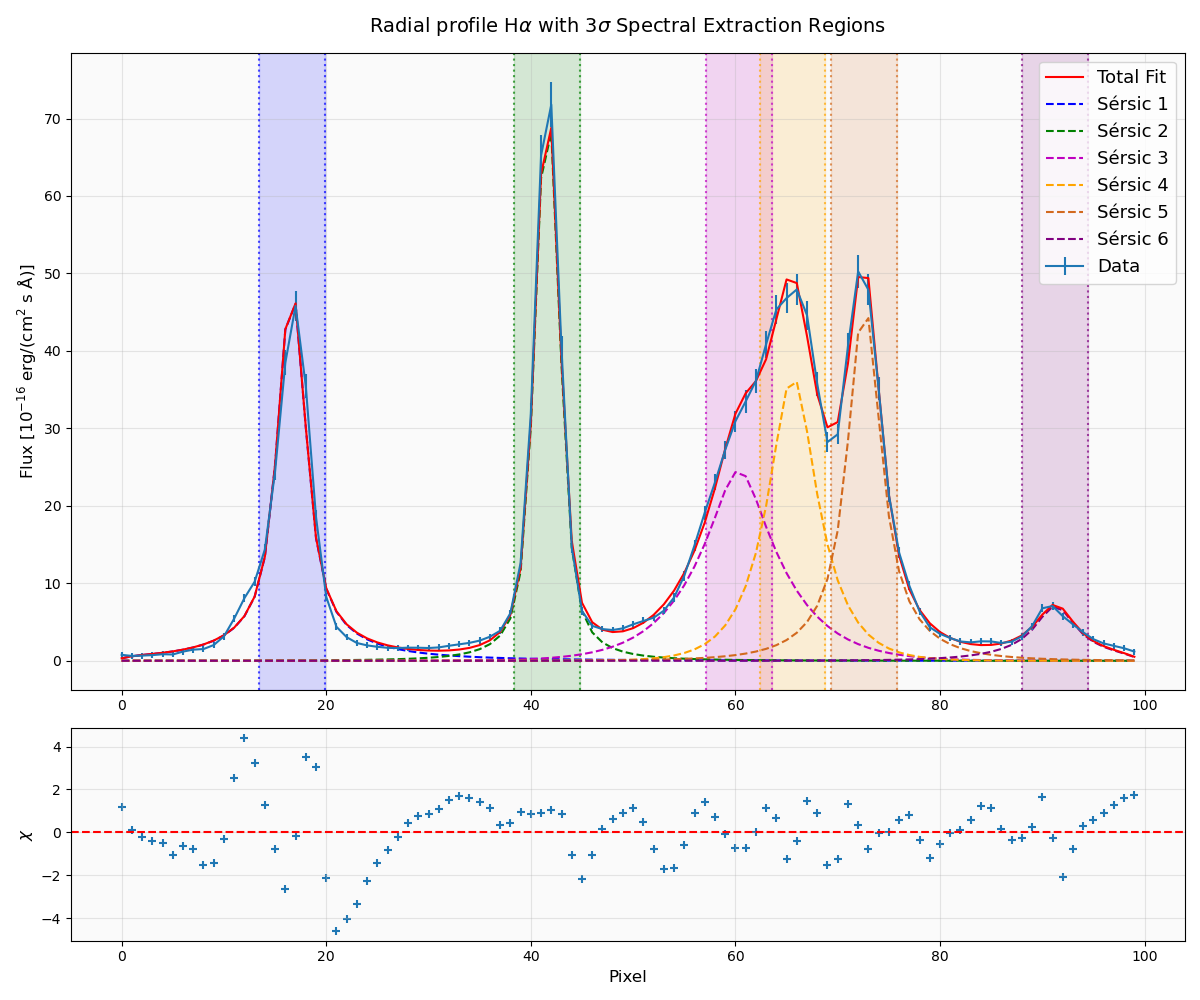

In [37]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/Halpha_fit.csv", index_col=0)
print(fit_HA)
plot_sigma_HA(1.0, sigmas[0], x_axes, fit_HA, radial_profile_HA, real_errors_HA, save_plot=True, output_dir="./")
plot_sigma_HA(2.0, sigmas[0], x_axes, fit_HA, radial_profile_HA, real_errors_HA, save_plot=True, output_dir="./")
plot_sigma_HA(3.0, sigmas[0], x_axes, fit_HA, radial_profile_HA, real_errors_HA, save_plot=True, output_dir="./")

Plot salvato come: ./Halpha_20ext.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

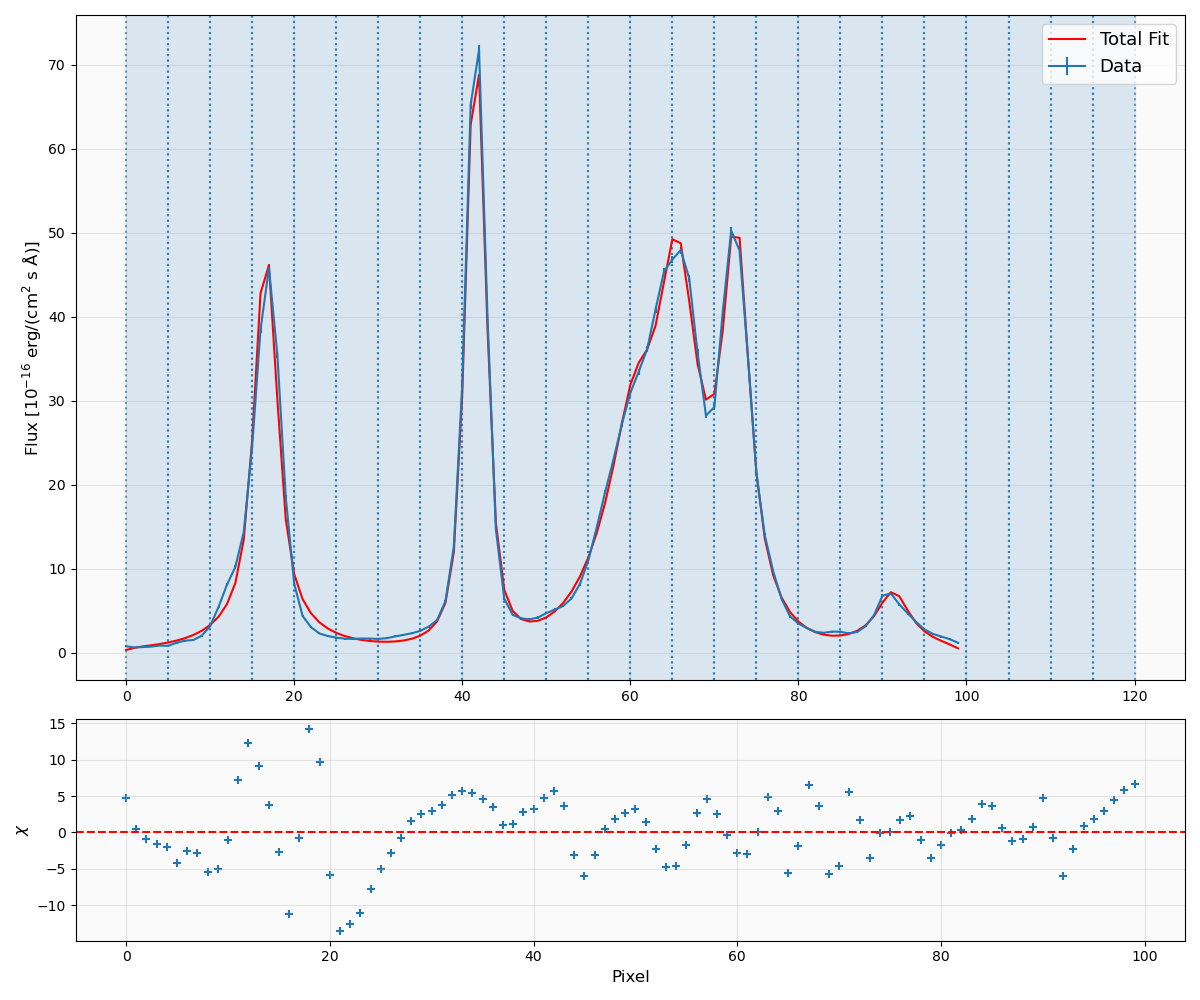

In [38]:
def plot_20ext_HA(x_axes, sigma_HA, fit, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_HA, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    for i in range(24):
        x_min = i * 5
        x_max = x_min + 5
        ax[0].axvspan(x_min, x_max, alpha=0.15, zorder=1)
        ax[0].axvline(x_min, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(x_max, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    #ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 100)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        #sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Halpha_20ext.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

plot_20ext_HA(x_axes, sigmas[0], fit_HA, radial_profile_HA, radial_profile_error_HA, save_plot=True, output_dir="./")

## Hbeta

Text(0.5, 1.0, 'H$\\beta$')

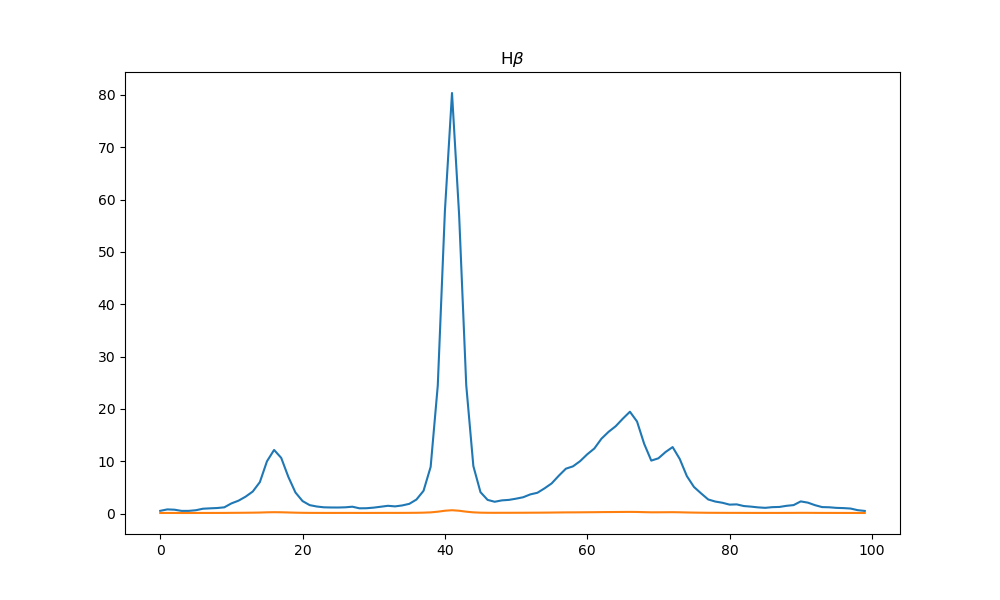

In [39]:
mask_HB = (wavelenghts > l_HB-8)*(wavelenghts < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [40]:
def plot_sigma_HB(sigma_extraction, sigma_HB, x_axes, fit, fit_HA, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_HB, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange', 'chocolate', 'purple']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigma_HB, np.array(fit[comp_name]))
        ax[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit_HA[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile H$\\beta$ with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 100)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"Hbeta_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12956\2575840244.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./Hbeta_1sigma.png
Plot salvato come: ./Hbeta_2sigma.png
Plot salvato come: ./Hbeta_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile H$\\beta$ with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

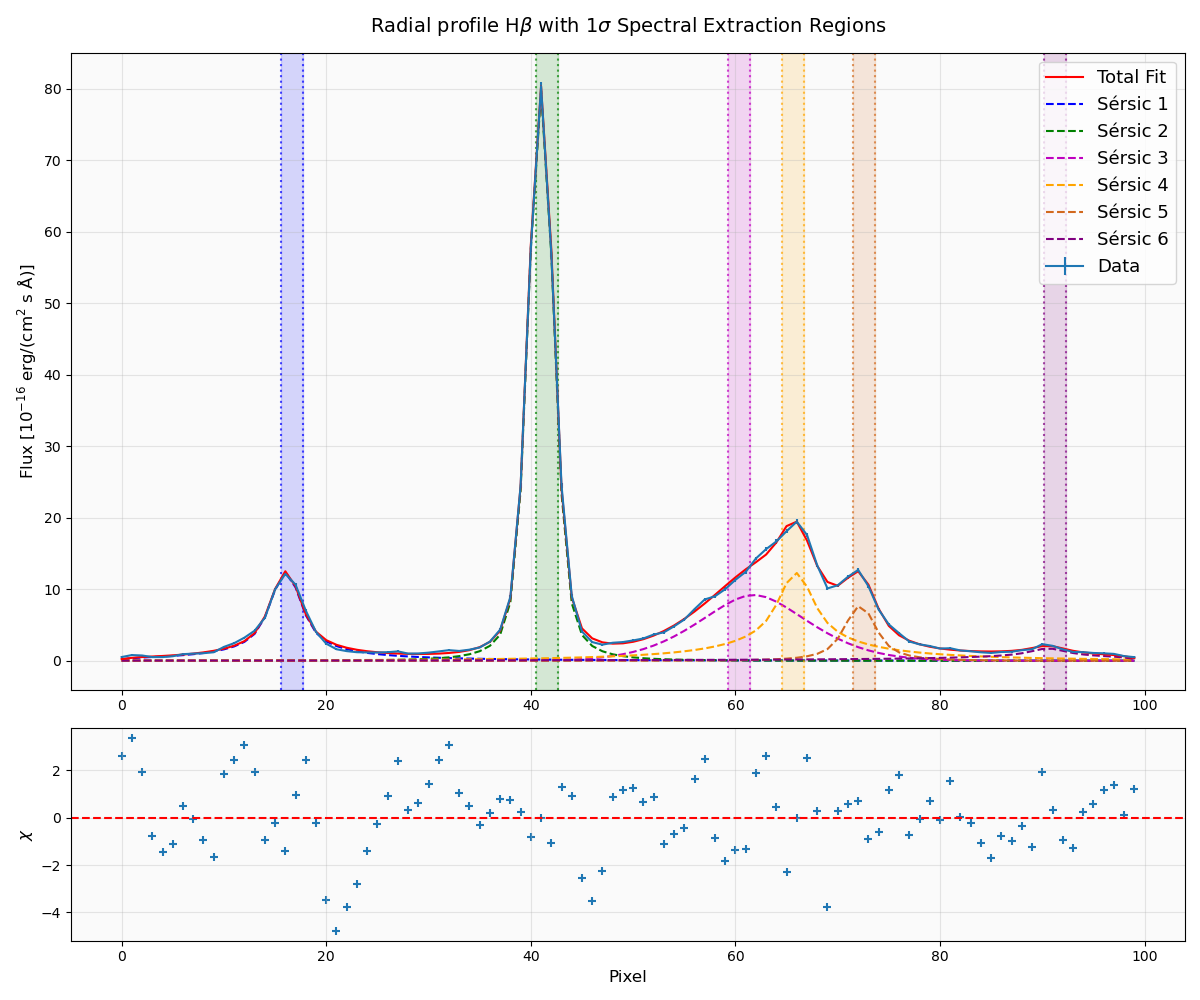

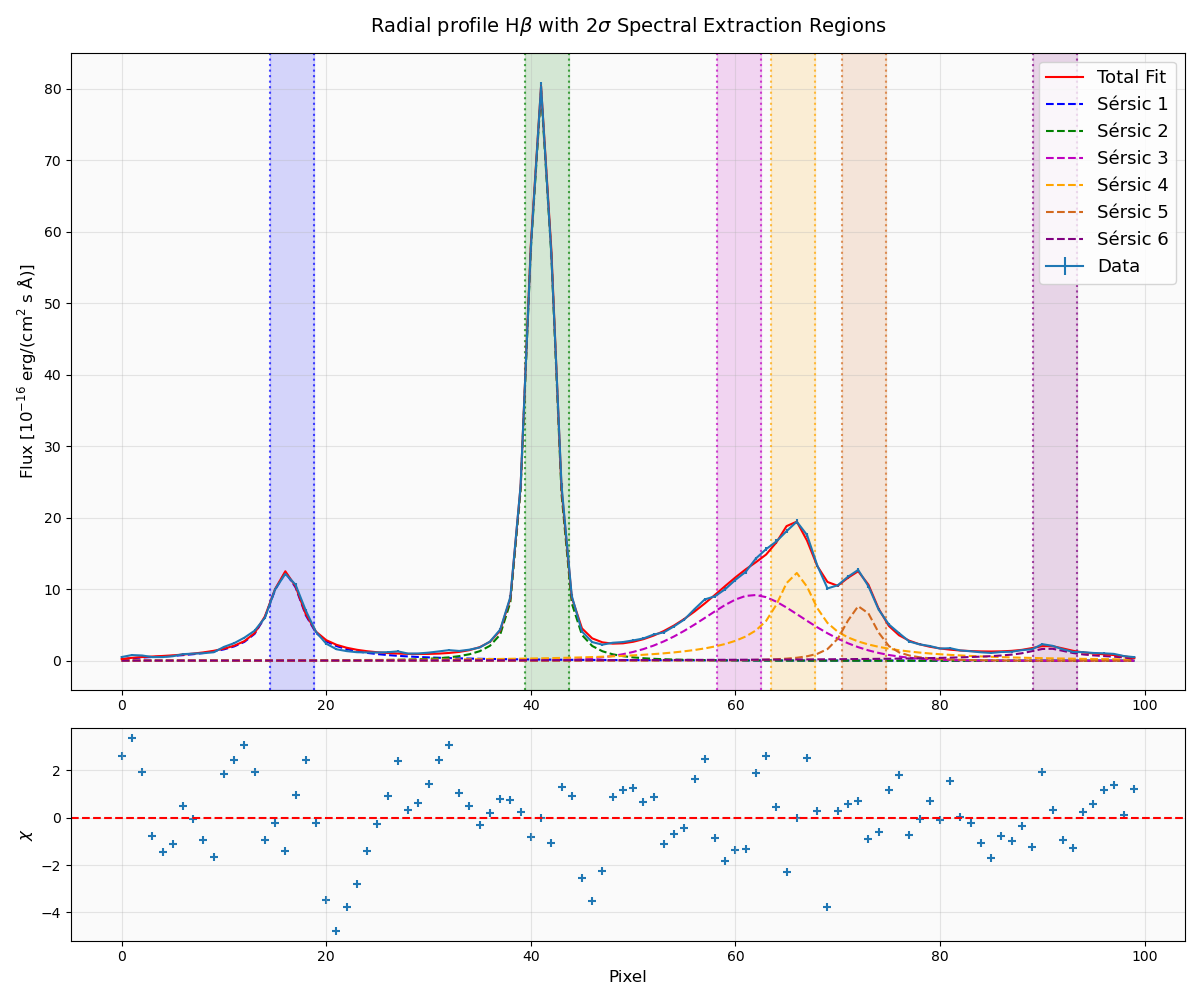

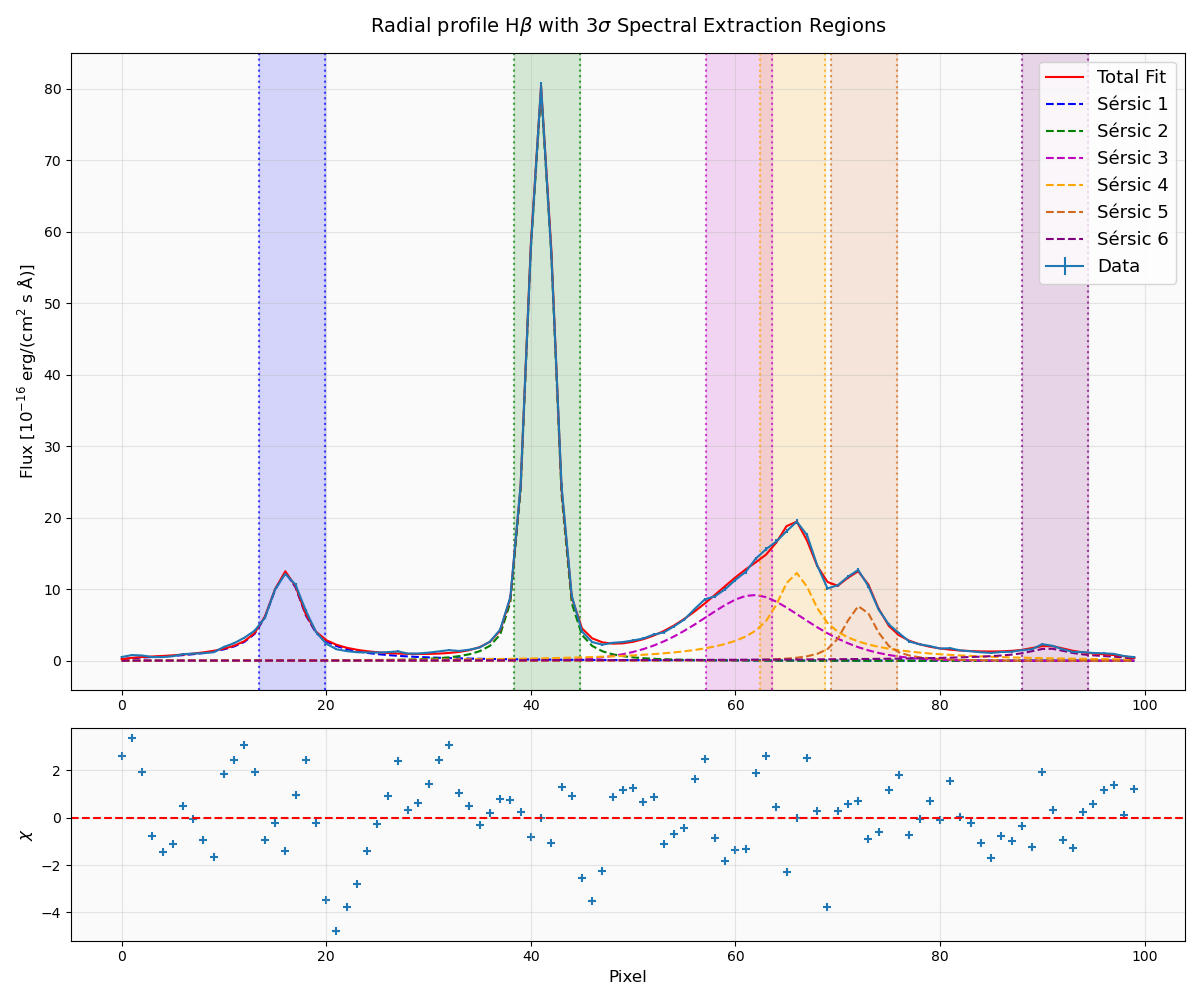

In [41]:
fit_HB = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/Hbeta_fit.csv", index_col = 0)
plot_sigma_HB(1.0, sigmas[1], x_axes, fit_HB, fit_HA, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")
plot_sigma_HB(2.0, sigmas[1], x_axes, fit_HB, fit_HA, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")
plot_sigma_HB(3.0, sigmas[1], x_axes, fit_HB, fit_HA, radial_profile_HB, radial_profile_error_HB, save_plot=True, output_dir="./")

## NII

Text(0.5, 1.0, '[NII]')

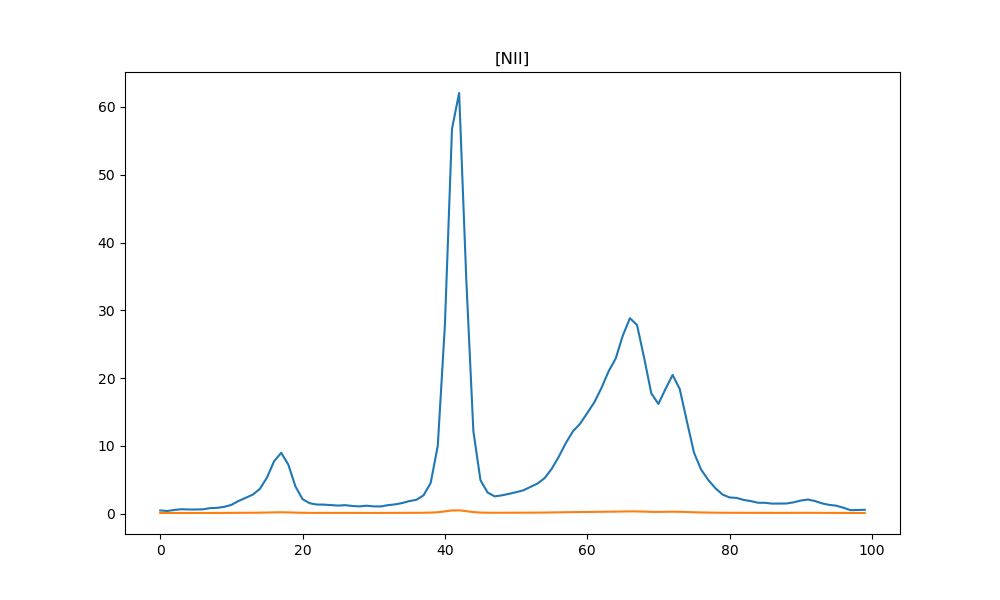

In [42]:
mask_NII = (wavelenghts > l_NII-8)*(wavelenghts < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [43]:
def plot_sigma_NII(sigma_extraction, sigma_NII, x_axes, fit, fit_HA, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_NII, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange', 'chocolate', 'purple']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigma_NII, np.array(fit[comp_name]))
        ax[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit_HA[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [NII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 100)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"NII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12956\2349206288.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./NII_1sigma.png
Plot salvato come: ./NII_2sigma.png
Plot salvato come: ./NII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [NII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

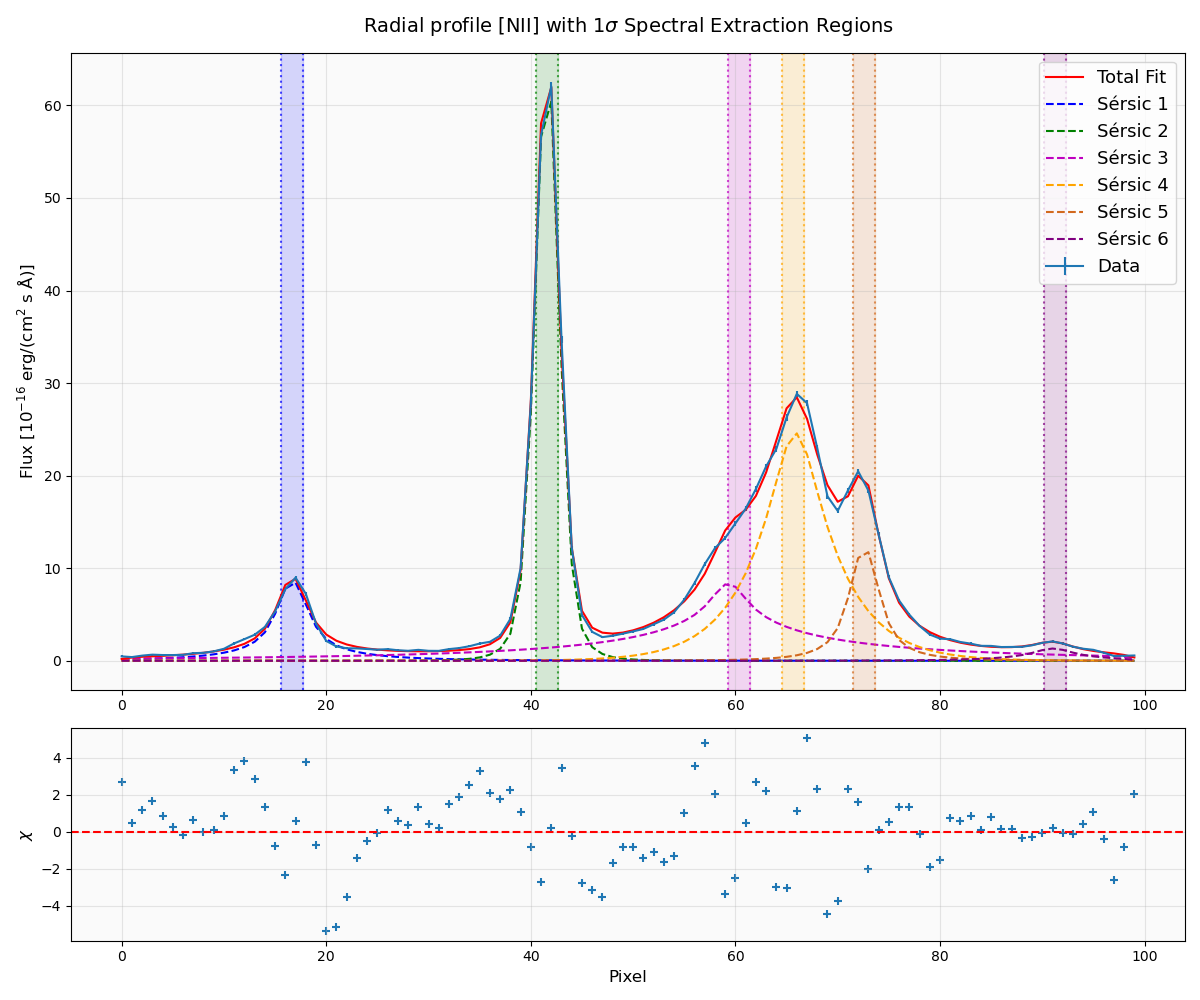

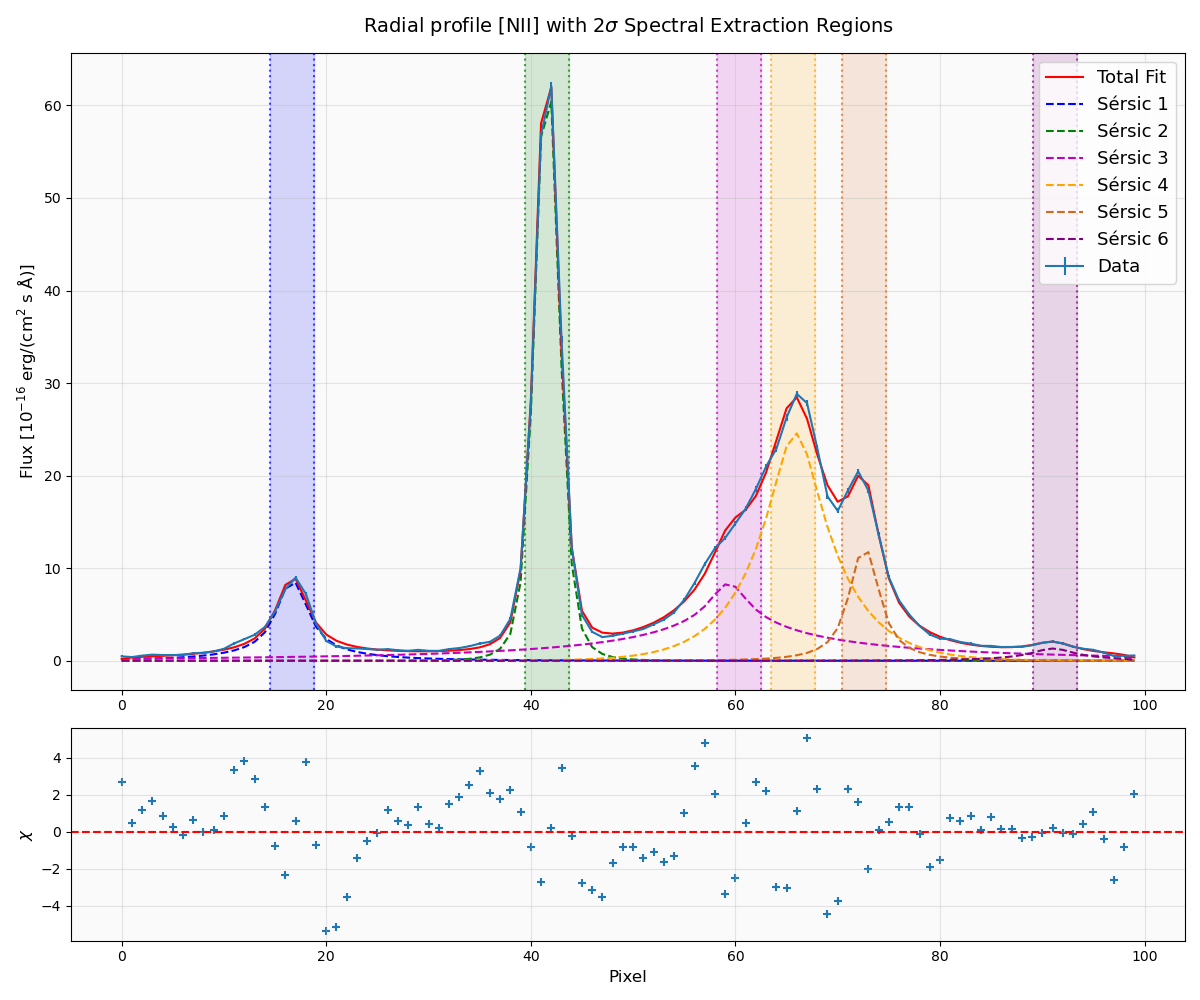

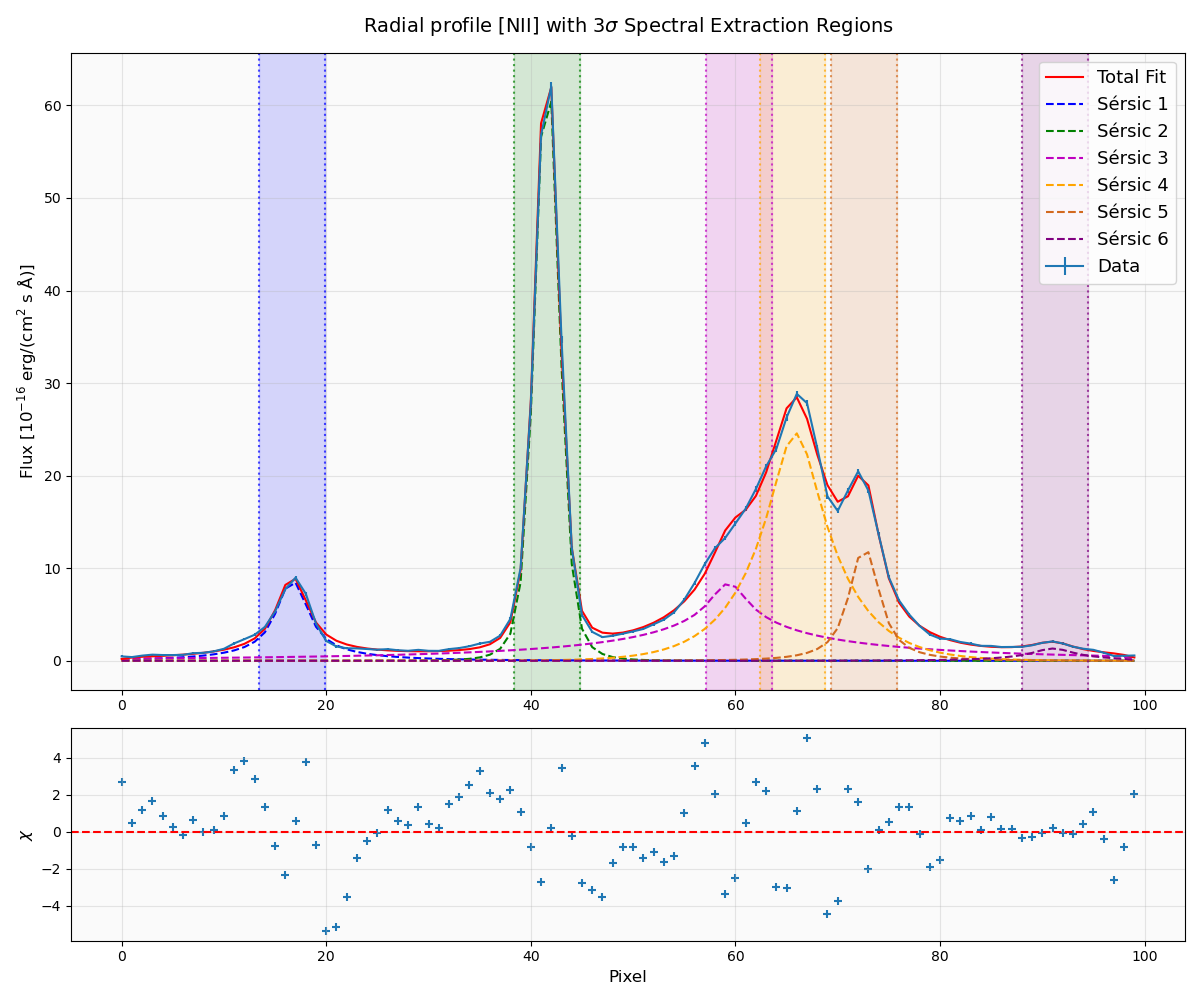

In [44]:
fit_NII =pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/NII_fit.csv", index_col = 0)
plot_sigma_NII(1.0, sigmas[2], x_axes, fit_NII, fit_HA, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")
plot_sigma_NII(2.0, sigmas[2], x_axes, fit_NII, fit_HA, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")
plot_sigma_NII(3.0, sigmas[2], x_axes, fit_NII, fit_HA, radial_profile_NII, radial_profile_error_NII, save_plot=True, output_dir="./")

## SII

Text(0.5, 1.0, '[SII]')

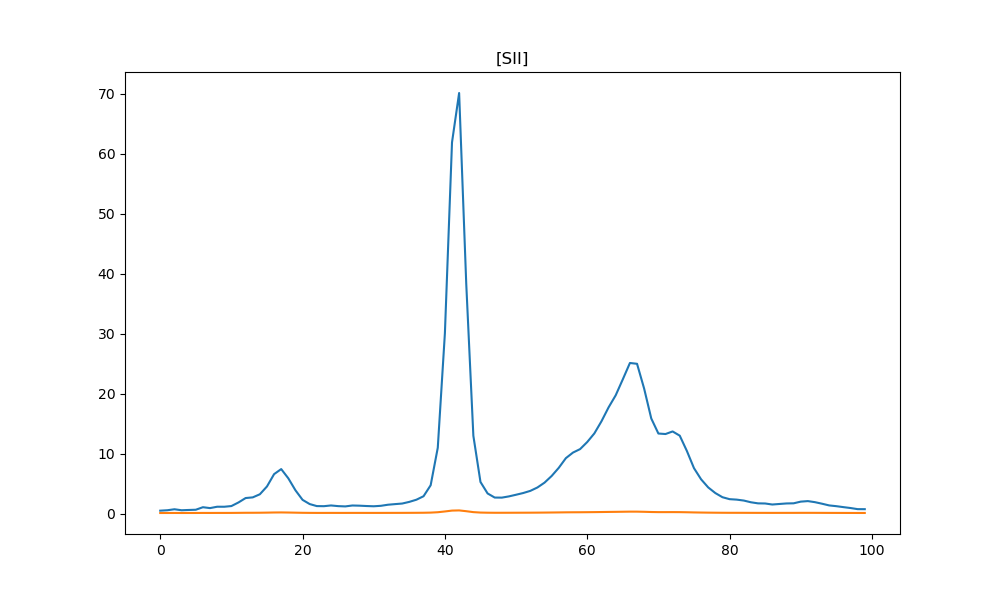

In [45]:
mask_SII = (wavelenghts > l_SII-8)*(wavelenghts < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [46]:
def plot_sigma_SII(sigma_extraction, sigma_SII, x_axes, fit, fit_HA, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_SII, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange', 'chocolate', 'purple']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigma_SII, np.array(fit[comp_name]))
        ax[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit_HA[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [SII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 100)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"SII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12956\2029888601.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./SII_1sigma.png
Plot salvato come: ./SII_2sigma.png
Plot salvato come: ./SII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [SII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

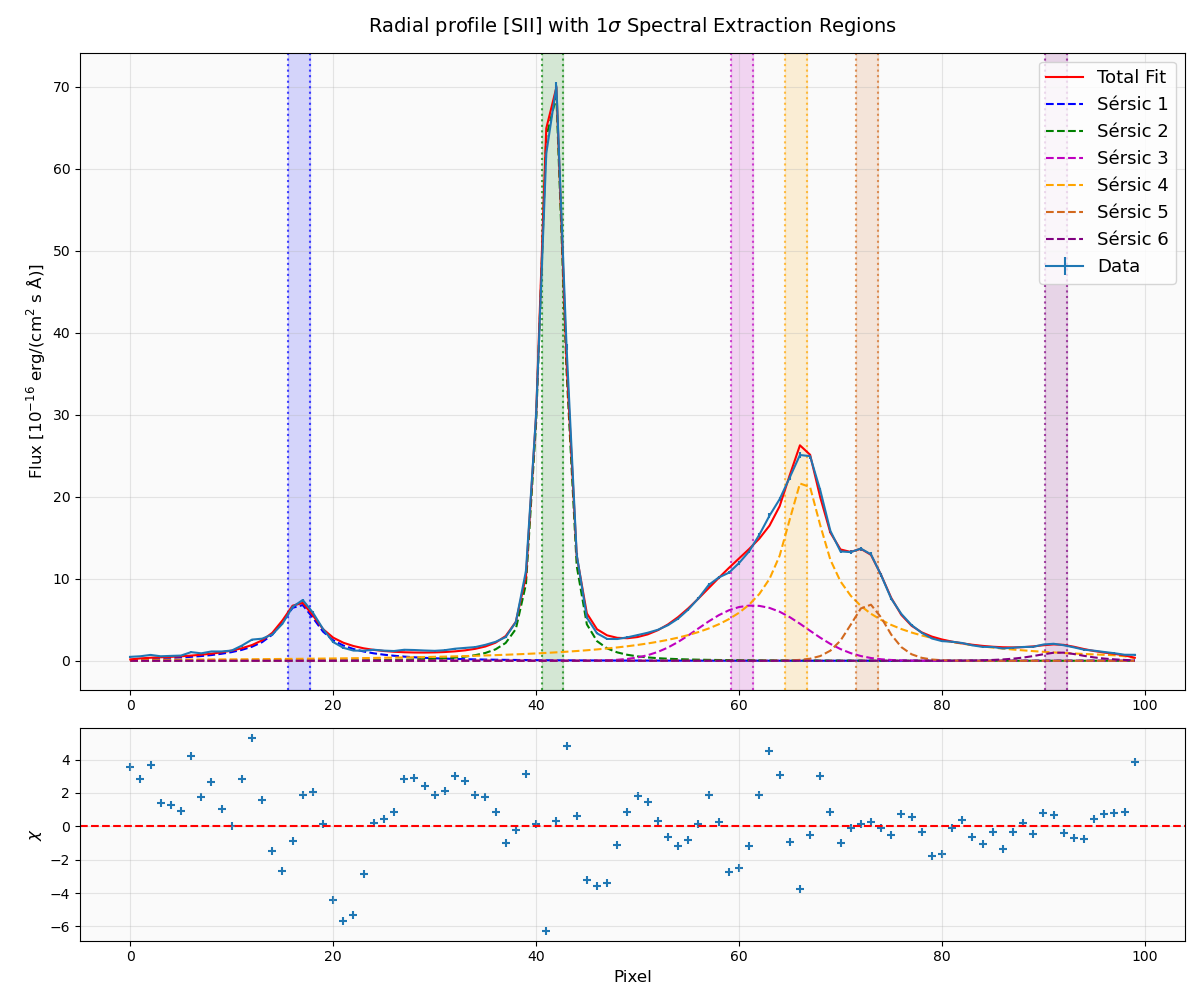

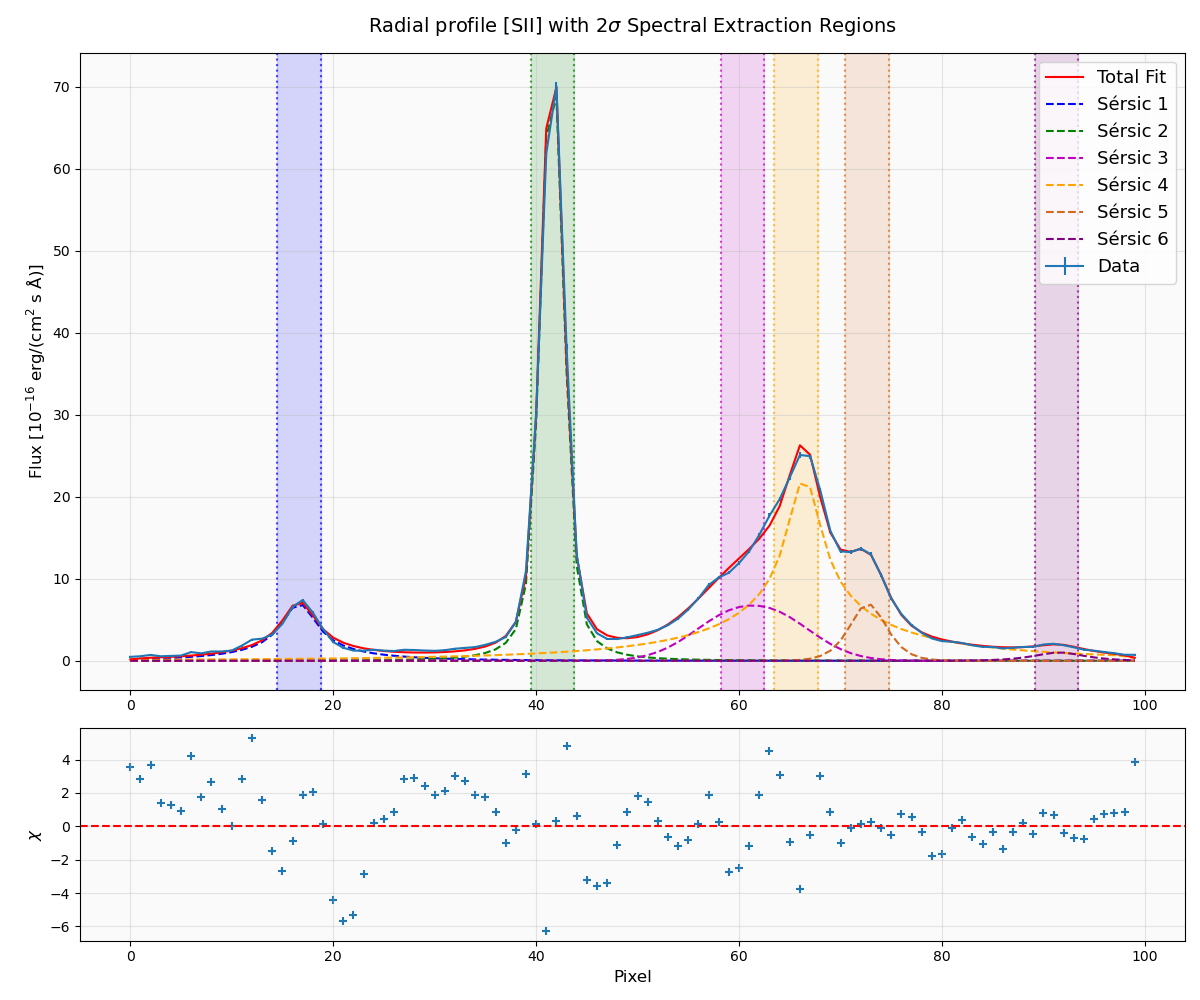

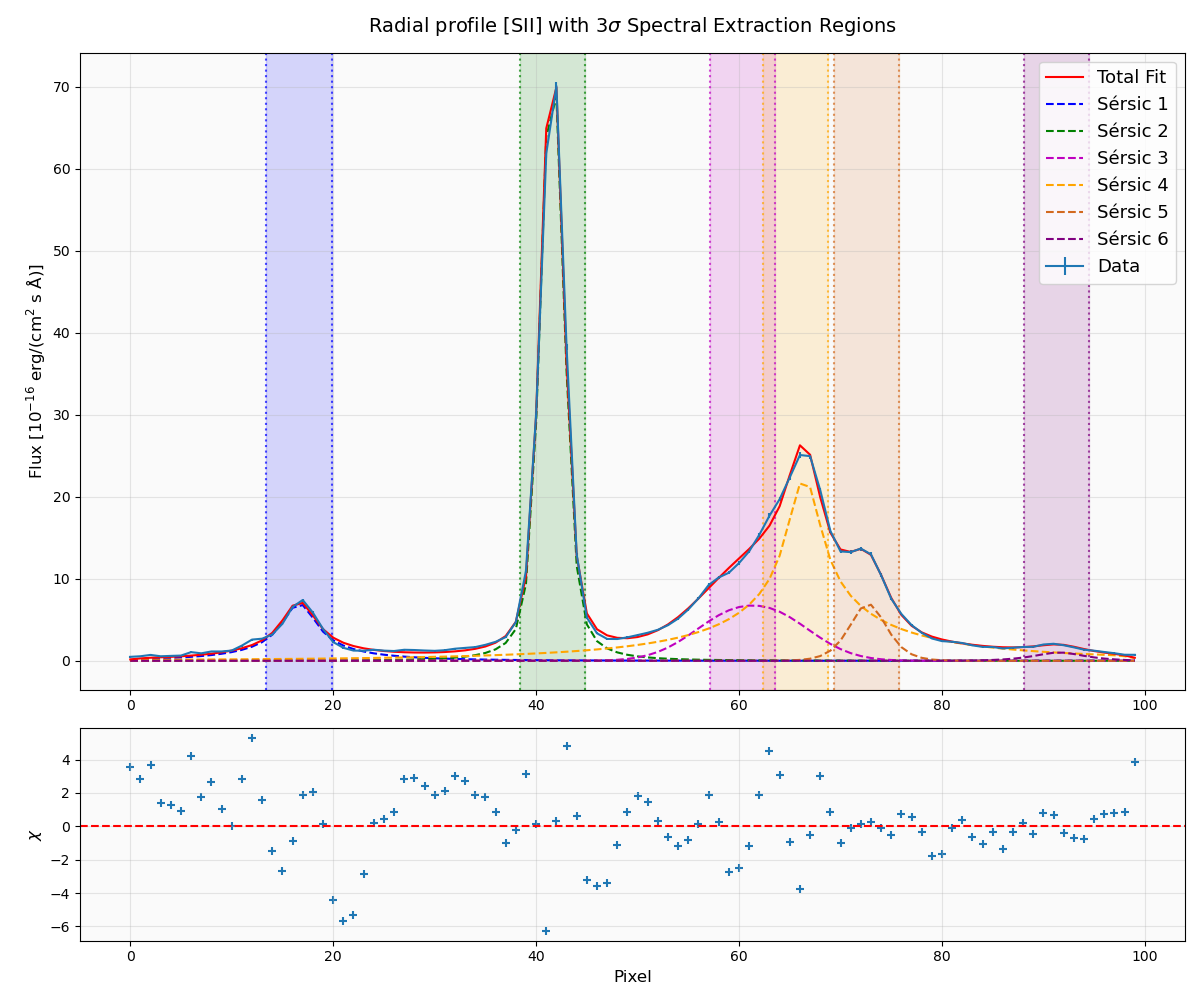

In [47]:
fit_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/SII_fit.csv", index_col = 0)
plot_sigma_SII(1.0, sigmas[3], x_axes, fit_SII, fit_HA, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")
plot_sigma_SII(2.0, sigmas[3], x_axes, fit_SII, fit_HA, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")
plot_sigma_SII(3.0, sigmas[3], x_axes, fit_SII, fit_HA, radial_profile_SII, radial_profile_error_SII, save_plot=True, output_dir="./")

## OIII

Text(0.5, 1.0, '[OIII]')

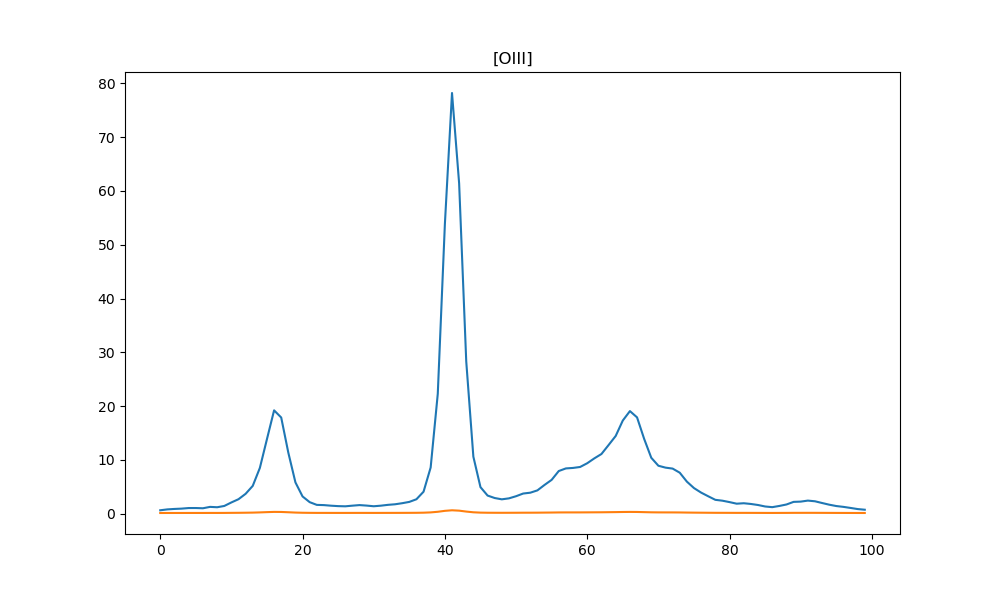

In [48]:
mask_OIII = (wavelenghts > l_OIII-8)*(wavelenghts < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [49]:
def plot_sigma_OIII(sigma_extraction, sigma_OIII, x_axes, fit, fit_HA, radial_profile, radial_profile_error, save_plot=True, output_dir="./"):
    
    #xgrid = np.linspace(min(x_axes), max(x_axes), 100)
    y_fit = model_convolved(x_axes, sigma_OIII, fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    ax[0].errorbar(x_axes, radial_profile, radial_profile_error, label='Data', zorder=3)
    ax[0].plot(x_axes, y_fit, 'r', label='Total Fit', zorder=3)
    
    colors = ['b', 'g', 'm', 'orange', 'chocolate', 'purple']  
    components = ['Component 1', 'Component 2', 'Component 3', 'Component 4', 'Component 5', 'Component 6']
    
    for i, comp_name in enumerate(components):
        color = colors[i]
        
        y_comp = sersic_1d_convolved(x_axes, sigma_OIII, np.array(fit[comp_name]))
        ax[0].plot(x_axes, y_comp, '--', color=color,  
                  label=f'Sérsic {i+1}')
        
        params = fit_HA[comp_name]
        center = params[3] 
        
        left_region = center - sigma_extraction * sigma 
        right_region = center + sigma_extraction * sigma 
        
        ax[0].axvspan(left_region, right_region, alpha=0.15, color=color, zorder=1)
        
        ax[0].axvline(left_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax[0].axvline(right_region, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Genera automaticamente il titolo
    sigma_text = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}"
    title = f"Radial profile [OIII] with {sigma_text}$\\sigma$ Spectral Extraction Regions"
    
    # Impostazioni del plot principale
    ax[0].set_ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
    ax[0].set_title(title, fontsize=14, pad=15)
    ax[0].legend(loc='upper right', fontsize=13)
    ax[0].grid(True, alpha=0.3)
    #ax[0].set_ylim(0, 12.5)
    ax[0].set_facecolor('#FAFAFA')
    
    # Plot dei residui
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error, marker='+')
    ax[1].axhline(0, color='red', linestyle='dashed')
    ax[1].set_xlabel("Pixel", fontsize=12)
    ax[1].set_ylabel(r'$\chi$', fontsize=12)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    
    if save_plot:
        # Genera il nome del file
        sigma_str = f"{int(sigma_extraction)}" if sigma_extraction.is_integer() else f"{sigma_extraction:.1f}".replace(".", "p")
        filename = f"OIII_{sigma_str}sigma.png"
        filepath = os.path.join(output_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot salvato come: {filepath}")
        
    return fig, ax

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_12956\1054259422.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center = params[3]


Plot salvato come: ./OIII_1sigma.png
Plot salvato come: ./OIII_2sigma.png
Plot salvato come: ./OIII_3sigma.png


(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Radial profile [OIII] with 3$\\sigma$ Spectral Extraction Regions'}, ylabel='Flux [$10^{-16}$ erg/(cm$^2$ s Å)]'>,
        <Axes: xlabel='Pixel', ylabel='$\\chi$'>], dtype=object))

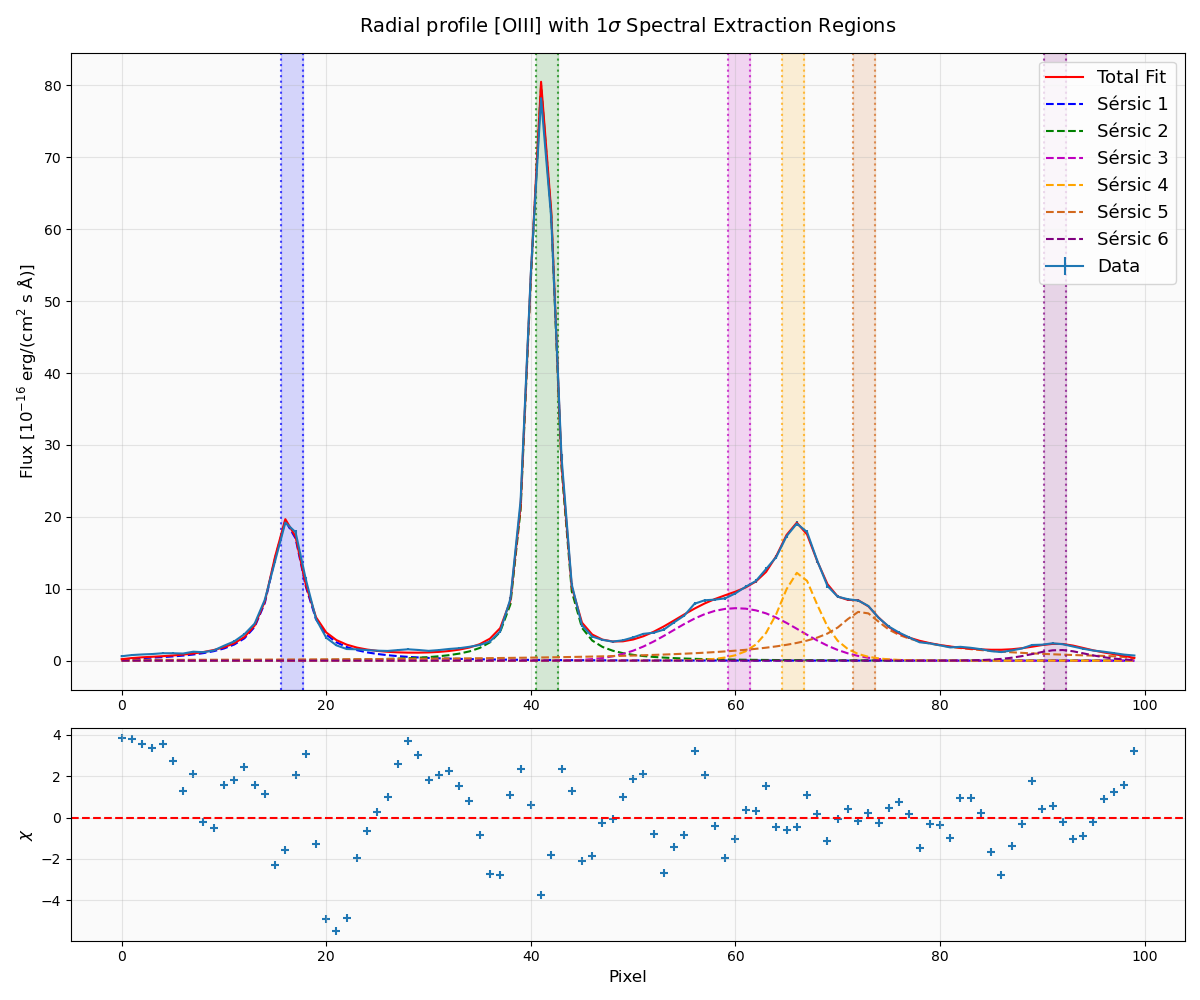

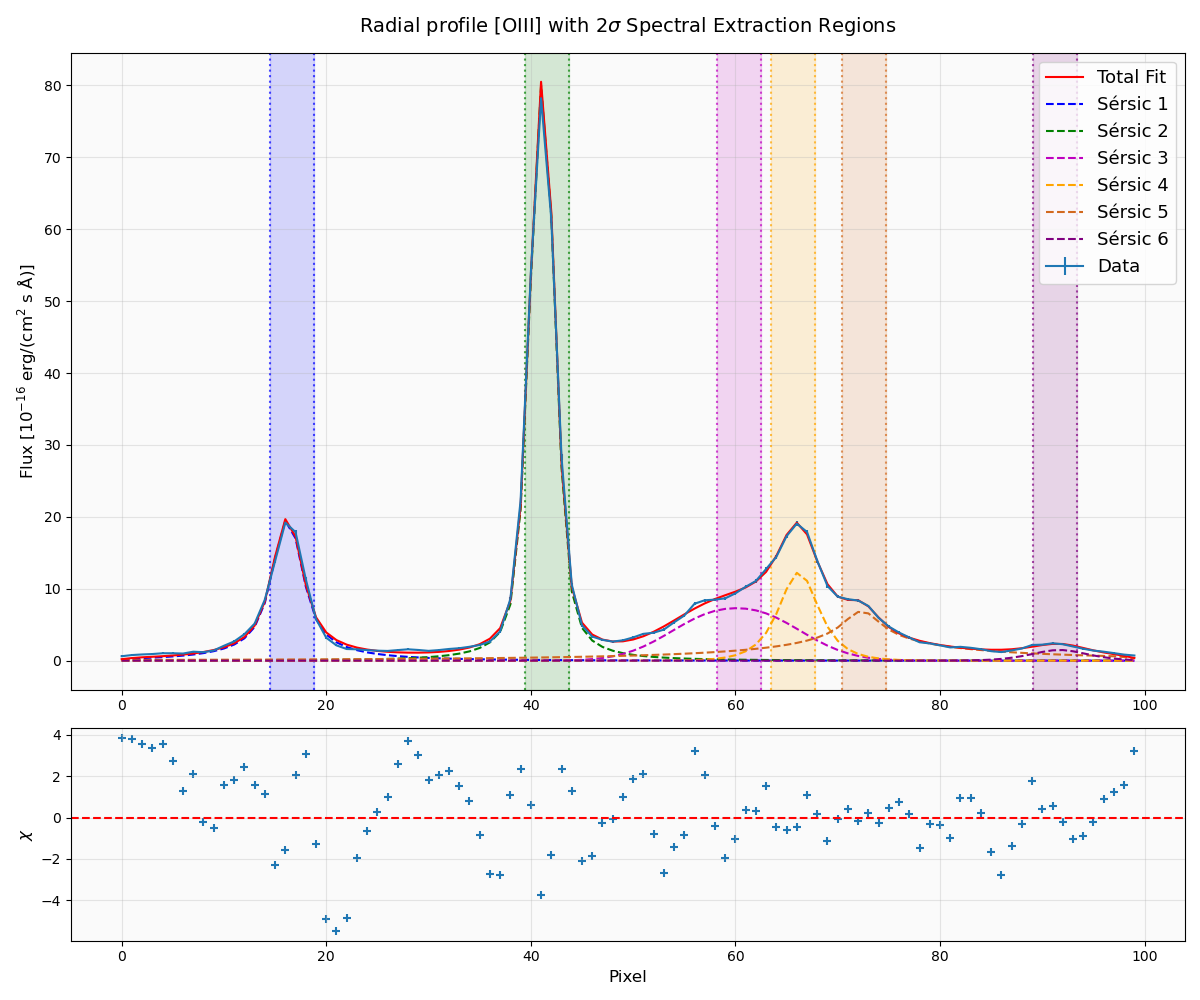

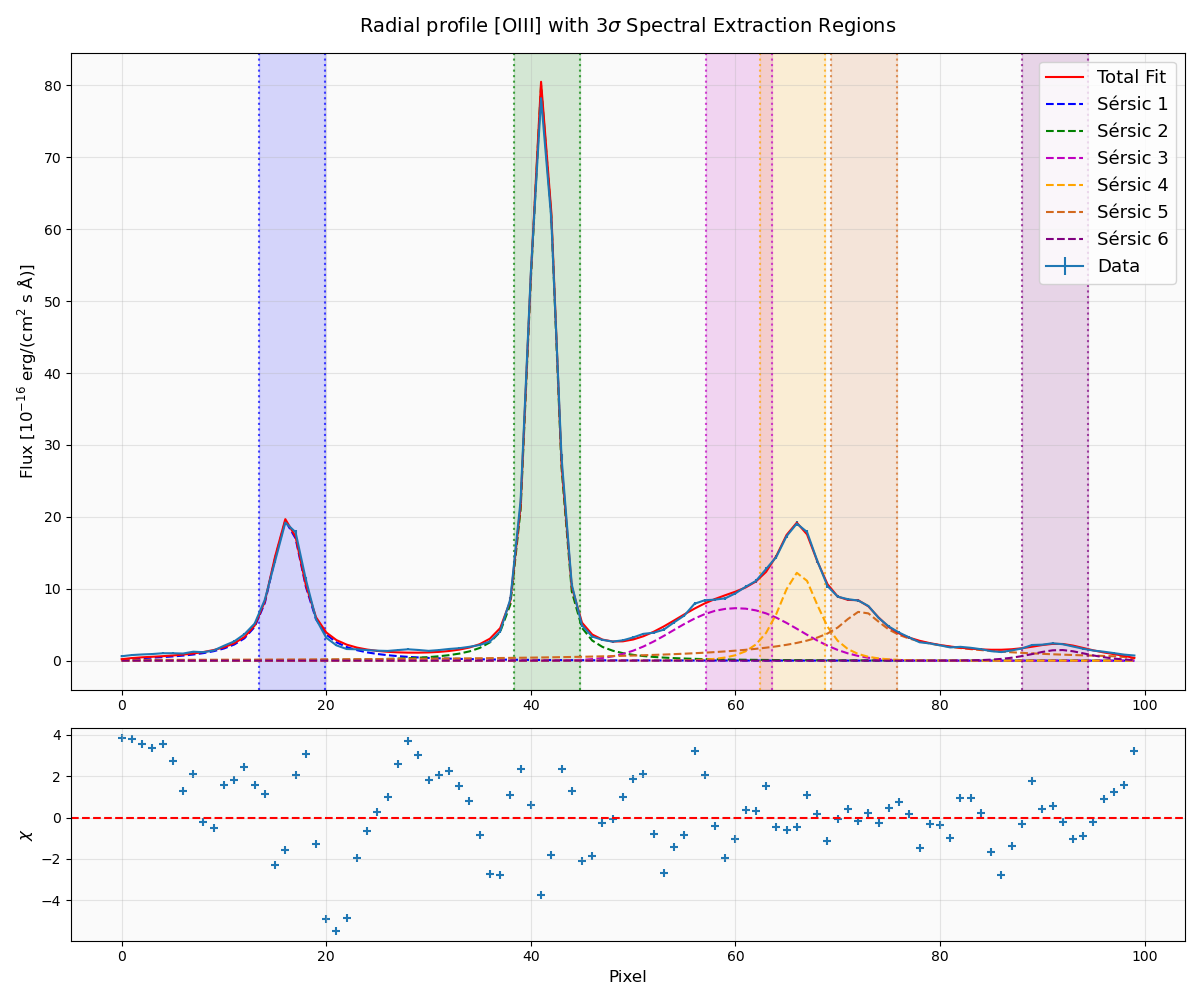

In [50]:
fit_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/OIII_fit.csv", index_col = 0)
plot_sigma_OIII(1.0, sigmas[4], x_axes, fit_OIII, fit_HA, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")
plot_sigma_OIII(2.0, sigmas[4], x_axes, fit_OIII, fit_HA, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")
plot_sigma_OIII(3.0, sigmas[4], x_axes, fit_OIII, fit_HA, radial_profile_OIII, radial_profile_error_OIII, save_plot=True, output_dir="./")